## 0. Get setup

In [ ]:
# For this notebook to run with updated APIs, we need torch 1.12+ and torchvision 0.13+
try:
    import torch
    import torchvision
    assert int(torch.__version__.split(".")[1]) >= 12, "torch version should be 1.12+"
    assert int(torchvision.__version__.split(".")[1]) >= 13, "torchvision version should be 0.13+"
    print(f"torch version: {torch.__version__}")
    print(f"torchvision version: {torchvision.__version__}")
except:
    print(f"[INFO] torch/torchvision versions not as required, installing nightly versions.")
    !pip3 install -U torch torchvision torchaudio --extra-index-url https://download.pytorch.org/whl/cu113
    import torch
    import torchvision
    print(f"torch version: {torch.__version__}")
    print(f"torchvision version: {torchvision.__version__}")

[INFO] torch/torchvision versions not as required, installing nightly versions.
Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cu113
torch version: 2.10.0+cu128
torchvision version: 0.25.0+cu128


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from torch import nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
try:
    from torchinfo import summary
except:
    print("torchinfo not found, installing...")
    %pip install torchinfo
    from torchinfo import summary
try:
     from going_modular import data_setup, engine
except:
    print("going_modular not found, installing...")
    !git clone https://github.com/mrdbourke/pytorch-deep-learning
    !mv pytorch-deep-learning/going_modular/going_modular/ .
    !rm -rf pytorch-deep-learning
    from going_modular import data_setup, engine

torchinfo not found, installing...
going_modular not found, installing...
Cloning into 'pytorch-deep-learning'...
remote: Enumerating objects: 4410, done.
remote: Counting objects: 100% (10/10), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 4410 (delta 5), reused 2 (delta 2), pack-reused 4400 (from 2)
Receiving objects: 100% (4410/4410), 764.18 MiB | 20.31 MiB/s, done.
Resolving deltas: 100% (2662/2662), done.
Updating files: 100% (248/248), done.


### Using a pretrained ViT from `torchvision.models`

In [ ]:
# The following requires torch v0.12+ and torchvision 0.13+
import torch
import torchvision
print(torch.__version__)
print(torchvision.__version__)

2.10.0+cu128
0.25.0+cu128


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

4. Creating a ViT feature extractor

In [ ]:
# Check out the ViT heads layer
vit = torchvision.models.vit_b_16()
vit.heads

Sequential(
  (head): Linear(in_features=768, out_features=1000, bias=True)
)

In [ ]:
def create_vit_model(num_classes:int=10,
                     seed:int=42):
    # Create a ViT_B_16 pretrained weights, transforms and model
    weights = torchvision.models.ViT_B_16_Weights.DEFAULT
    transforms = weights.transforms()
    model = torchvision.models.vit_b_16(weights=weights).to(device)

    # Freeze all of the base layers
    for param in model.parameters():
        param.requires_grad = False

    # Change the classifier head to suit our needs
    model.heads = nn.Sequential(
        nn.Linear(in_features=768,out_features=num_classes,bias=True)
    )
    return model, transforms

In [ ]:
vit, vit_transforms = create_vit_model()
vit_transforms

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:03<00:00, 89.3MB/s]


ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

In [ ]:
from torchinfo import summary
summary(vit,
        input_size=(1, 3, 224, 224),
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"]
)

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
VisionTransformer (VisionTransformer)                        [1, 3, 224, 224]     [1, 10]              768                  Partial
├─Conv2d (conv_proj)                                         [1, 3, 224, 224]     [1, 768, 14, 14]     (590,592)            False
├─Encoder (encoder)                                          [1, 197, 768]        [1, 197, 768]        151,296              False
│    └─Dropout (dropout)                                     [1, 197, 768]        [1, 197, 768]        --                   --
│    └─Sequential (layers)                                   [1, 197, 768]        [1, 197, 768]        --                   False
│    │    └─EncoderBlock (encoder_layer_0)                   [1, 197, 768]        [1, 197, 768]        (7,087,872)          False
│    │    └─EncoderBlock (encoder_layer_1)                   [1, 197, 768]        [1, 1

### Create the Dataset and DataLoaders

In [ ]:
# Create train and test datasets
import torchvision
train_dataset = torchvision.datasets.CIFAR10(root=".", # Where to store data
                                             train=True, # do we want the train dataset ?
                                             download=True,
                                             transform=vit_transforms)
test_dataset = torchvision.datasets.CIFAR10(root=".", # Where to store data
                                             train=False, # do we want the train dataset ?
                                             download=True,
                                             transform=vit_transforms)
# Get the length of the train and test datasets
train_len = len(train_dataset)
test_len = len(test_dataset)
print(f"[INFO] Length of train dataset: {train_len}")
print(f"[INFO] Length of test dataset: {test_len}")

100%|██████████| 170M/170M [00:18<00:00, 9.06MB/s]


[INFO] Length of train dataset: 50000
[INFO] Length of test dataset: 10000


In [ ]:
import os
batch_size = 32
num_workers = os.cpu_count()
# Get class names
class_names = train_dataset.classes
# Turn images into data loaders
train_dataloader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=True,
)
test_dataloader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True,
)

### Training ViT Feature Extractor

In [ ]:
from going_modular import engine

# Loss Function
loss_fn = nn.CrossEntropyLoss()
# Optimizer
optimizer = torch.optim.Adam(vit.parameters(),lr=0.001)

# Training function (engine.py)
vit_results = engine.train(model=vit,
                                train_dataloader=train_dataloader,
                                test_dataloader=test_dataloader,
                                optimizer=optimizer,
                                loss_fn=loss_fn,
                                epochs=5,
                                device=device)

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.2138 | train_acc: 0.9346 | test_loss: 0.1723 | test_acc: 0.9437
Epoch: 2 | train_loss: 0.1407 | train_acc: 0.9536 | test_loss: 0.1605 | test_acc: 0.9482
Epoch: 3 | train_loss: 0.1245 | train_acc: 0.9588 | test_loss: 0.1596 | test_acc: 0.9486
Epoch: 4 | train_loss: 0.1154 | train_acc: 0.9610 | test_loss: 0.1543 | test_acc: 0.9500
Epoch: 5 | train_loss: 0.1078 | train_acc: 0.9640 | test_loss: 0.1602 | test_acc: 0.9478


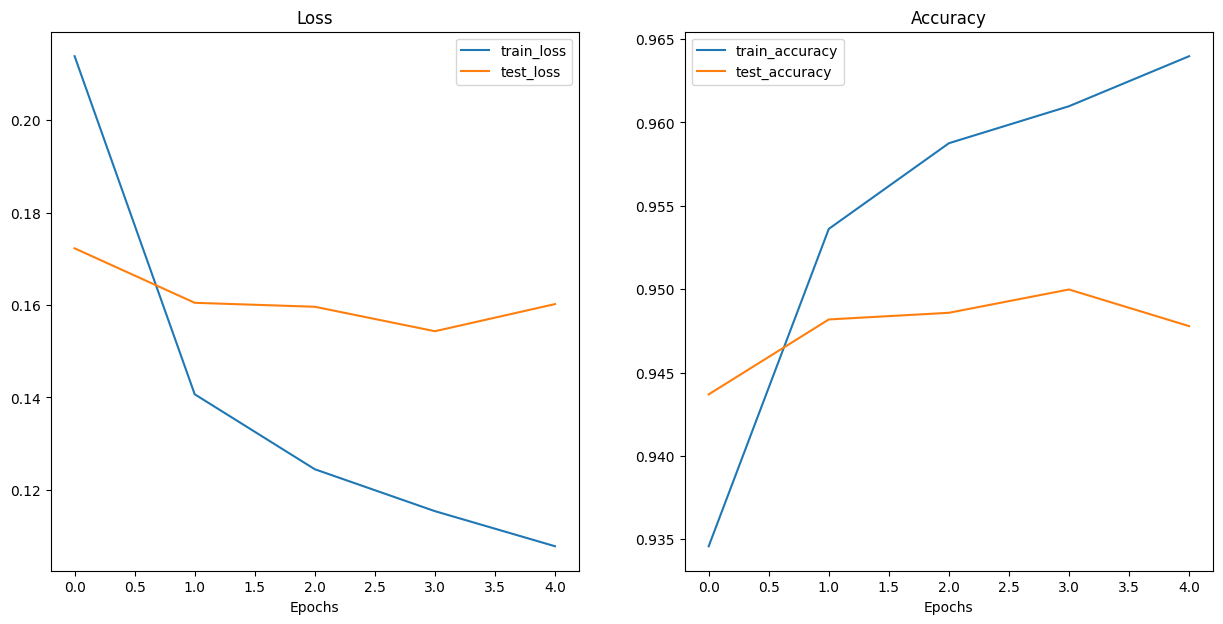

In [ ]:
from going_modular.helper_functions import plot_loss_curves
plot_loss_curves(vit_results)

### Saving ViT feature extractor

In [ ]:
from going_modular import utils
# Save the model
utils.save_model(model=vit,
                 target_dir="models",
                 model_name="CIFAR_Model.pth")

[INFO] Saving model to: models/CIFAR_Model.pth


In [ ]:
from pathlib import Path

# Get the model size in bytes and convert to megabytes (MB)
model_path = Path("models/CIFAR_Model.pth")
pretrained_vit_model_size = model_path.stat().st_size / (1024 * 1024)
print(f"Model size: {pretrained_vit_model_size:.2f} MB")

Model size: 327.38 MB


In [ ]:
# Count number of parameters in vit
vit_total_params = sum(torch.numel(param) for param in vit.parameters())
vit_total_params

85806346

In [ ]:
# Create a ViT Statistics dictionary
vit_stats = {"test_loss":vit_results["test_loss"][-1],
             "test_acc":vit_results["test_acc"][-1],
             "number_of_parameters":vit_total_params, # Corrected key name
             "model_size (MB)": pretrained_vit_model_size # Corrected key name
             }